# Linear regression

We want to approximate the following unkown (linear) function $f\colon \mathbb{R} \rightarrow \mathbb{R}$ with a linear model given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data. 

Import jax, numpy and matplotlib dependencies

In [9]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import jax
from jax import numpy as jnp
from jaxtyping import Array
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

Define _target function_. For instance, $x \mapsto f(x) = 4x + 1$

In [2]:
def f_fn(x):
    return 4*x + 1

Generate training data by evaluating the input at the apriori unknown function $f(x)$ and adding some Gaussian noise

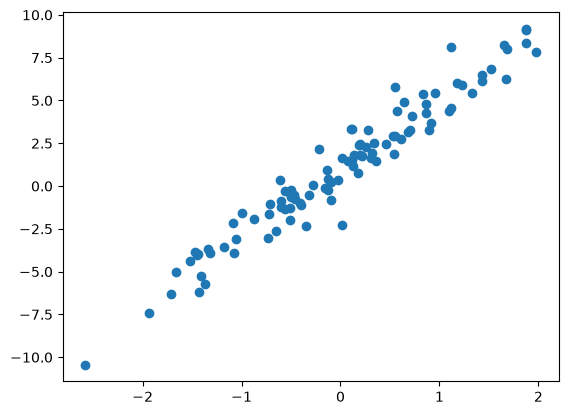

In [3]:
# sample K random points from the Gaussian distribution as input
K = 100
x_train = np.random.normal(size=K)

# sample Gaussian noise with mean=0 and std=1
noise = np.random.normal(loc=0, scale=1, size=K)

# generate target points y = 4x + 1 + eps, where eps is the Gaussian noise 
y_train = f_fn(x_train) + noise

# plot
plt.scatter(x_train, y_train);

We want to fit the linear model $\hat{y} =  w x + b$, with $\theta = (w, b)$

Define linear model

In [4]:
def model(theta: Array, x: np.ndarray) -> Array:
    '''
    Computes wx + b on a batch of input x.
    '''
    w, b = theta
    return w * x + b

Define MSE loss

In [5]:
def loss_fn(theta: Array, x: np.ndarray, y: np.ndarray) -> Array:
    '''
    Calculates the MSE loss.
    '''
    prediction = model(theta, x)  
    return jnp.mean((prediction - y) ** 2)

Define update function method

In [11]:
def update_step(theta: Array, x: np.ndarray,
                y: np.ndarray, lr: float = 0.1) -> Array:
    '''
    Evaluate loss, computes gradients and updates the parameters using SGD
    '''
    # evaluate loss and compute gradients
    loss_val, grads = jax.value_and_grad(loss_fn)(theta, x, y)

    # update parameters
    theta = theta - lr * grads
    
    return loss_val, theta

Initialize both parameters at 1

In [12]:
theta = jnp.array([1., 1.])
y_init = model(theta, x_train)

Train

In [13]:
lr = 1e-2
n_iter = int(1e2)
log_period_iter = int(1e1)
for i in range(n_iter):
    t0 = time()
    loss, theta = update_step(theta, x_train, y_train, lr)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss, t1-t0))

it: 0, loss: 9.203e+00, time: 0.0108s
it: 10, loss: 6.581e+00, time: 0.0026s
it: 20, loss: 4.788e+00, time: 0.0024s
it: 30, loss: 3.561e+00, time: 0.0017s
it: 40, loss: 2.723e+00, time: 0.0015s
it: 50, loss: 2.149e+00, time: 0.0016s
it: 60, loss: 1.757e+00, time: 0.0016s
it: 70, loss: 1.489e+00, time: 0.0014s
it: 80, loss: 1.305e+00, time: 0.0015s
it: 90, loss: 1.180e+00, time: 0.0021s


Evaluate results

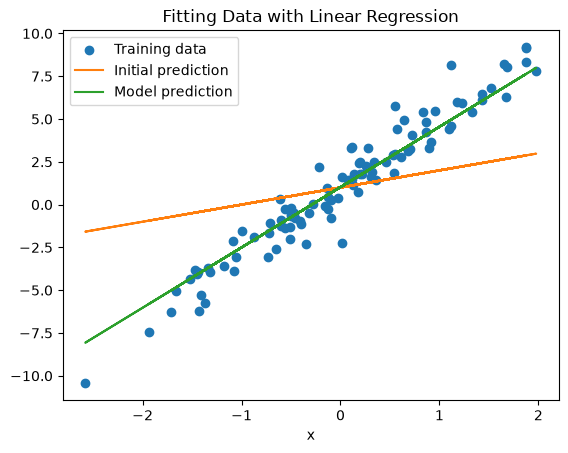

In [15]:
y_pred = model(theta, x_train)
fig, ax = plt.subplots()
ax.set_title('Fitting Data with Linear Regression');
ax.scatter(x_train, y_train, c='tab:blue', label='Training data')
ax.plot(x_train, y_init, c='tab:orange', label='Initial prediction')
ax.plot(x_train, y_pred, c='tab:green', label='Model prediction')
ax.set_xlabel('x')
ax.legend();

Display optimal weights

In [16]:
w, b = theta
print(f'w: {w:<.2f}, b: {b:<.2f}')

w: 3.52, b: 1.02


Compute _r2 score_

In [17]:
r2 = round(float(r2_score(y_train, y_pred)), 3)
print("R^2 Score:", r2)

R^2 Score: 0.93
